In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

def get_size(path):
    if path.is_file():
        return path.stat().st_size
    return sum(
        f.stat().st_size
        for f in path.rglob("*")
        if f.is_file()
    )

drive_root = Path("/content/drive/MyDrive")

items = sorted(
    drive_root.iterdir(),
    key=get_size,
    reverse=True
)

print(f"{'Size (GB)':>10}  Item")
print("-" * 60)

for item in items[:20]:
    size_gb = get_size(item) / (1024**3)
    print(f"{size_gb:10.2f}  {item.name}")

 Size (GB)  Item
------------------------------------------------------------
      1.70  AI_Midterm
      0.12  vgg16_checkpoint.keras
      0.11  Copy of user_jobs_anonymized.csv
      0.00  cifar_checkpoint.keras
      0.00  Colab Notebooks
      0.00  HW3_Kelly.ipynb
      0.00  Funding Knowledge_PowerPoint_FINAL (2).pptx
      0.00  HW1_DSBA6211.ipynb
      0.00  Copy of Lab8_Sequence_RNN_SV_completed.ipynb
      0.00  Kelly_K_Linear_Regression_Assignment.ipynb
      0.00  data_merged_clean.csv
      0.00  Exploratory Dashboard_Kelly_new.twb
      0.00  HW4_Kelly.ipynb
      0.00  cleaned_teacher_survey_USE THIS ONE.xlsx
      0.00  PCA.ipynb
      0.00  Bi Cheat Sheet exam 2 Copy.docx
      0.00  loan.csv
      0.00  good evening_kickstarter_use this one.docx
      0.00  kickstarter_campaign_intro.docx
      0.00  Midterm_Final_Kelly.drawio


In [ ]:
from pathlib import Path

midterm_root = Path(
    "/content/drive/MyDrive/AI_Midterm"
)

def get_size(path):
    if path.is_file():
        return path.stat().st_size

    return sum(
        file.stat().st_size
        for file in path.rglob("*")
        if file.is_file()
    )

items = sorted(
    midterm_root.iterdir(),
    key=get_size,
    reverse=True
)

print(f"{'Size (GB)':>10}  Item")
print("-" * 70)

for item in items:
    size_gb = get_size(item) / (1024 ** 3)

    print(
        f"{size_gb:10.2f}  {item.name}"
    )

In [ ]:
from pathlib import Path

checkpoint_root = Path(
    "/content/drive/MyDrive/AI_Midterm/checkpoints"
)

checkpoint_files = sorted(
    [
        path
        for path in checkpoint_root.rglob("*")
        if path.is_file()
    ],
    key=lambda path: path.stat().st_size,
    reverse=True,
)

print(f"{'Size (MB)':>10}  File")
print("-" * 100)

for path in checkpoint_files[:100]:
    size_mb = path.stat().st_size / (1024 ** 2)

    print(
        f"{size_mb:10.2f}  "
        f"{path.relative_to(checkpoint_root)}"
    )

In [ ]:
from pathlib import Path

SRGAN_CHECKPOINT_DIR = Path(
    "/content/drive/MyDrive/AI_Midterm/checkpoints/srgan"
)

KEEP_FILENAMES = {
    "srgan_latest_checkpoint.pth",
    "srgan_epoch_025.pth",
    "srgan_epoch_050.pth",
    "srgan_epoch_075.pth",
    "srgan_epoch_100.pth",
    "srgan_epoch_125.pth",
    "srgan_epoch_150.pth",
}

checkpoint_files = sorted(
    SRGAN_CHECKPOINT_DIR.glob("srgan_epoch_*.pth")
)

files_to_keep = [
    path
    for path in checkpoint_files
    if path.name in KEEP_FILENAMES
]

files_to_delete = [
    path
    for path in checkpoint_files
    if path.name not in KEEP_FILENAMES
]

space_to_recover_gb = sum(
    path.stat().st_size
    for path in files_to_delete
) / (1024 ** 3)

print("Files that will be kept:")
for path in files_to_keep:
    print(" KEEP:", path.name)

latest_checkpoint = (
    SRGAN_CHECKPOINT_DIR
    / "srgan_latest_checkpoint.pth"
)

if latest_checkpoint.exists():
    print(" KEEP:", latest_checkpoint.name)

print()
print(
    "Number of epoch checkpoints to delete:",
    len(files_to_delete)
)

print(
    "Estimated storage recovered:",
    round(space_to_recover_gb, 2),
    "GB"
)

print()
print("First 20 files that would be deleted:")

for path in files_to_delete[:20]:
    print(" DELETE:", path.name)

Files that will be kept:
 KEEP: srgan_epoch_025.pth
 KEEP: srgan_epoch_050.pth
 KEEP: srgan_epoch_075.pth
 KEEP: srgan_epoch_100.pth
 KEEP: srgan_epoch_125.pth
 KEEP: srgan_epoch_150.pth
 KEEP: srgan_latest_checkpoint.pth

Number of epoch checkpoints to delete: 0
Estimated storage recovered: 0.0 GB

First 20 files that would be deleted:


In [ ]:
deleted_count = 0
deleted_bytes = 0

for checkpoint_path in files_to_delete:
    deleted_bytes += checkpoint_path.stat().st_size
    checkpoint_path.unlink()
    deleted_count += 1

print("Checkpoint files deleted:", deleted_count)

print(
    "Storage recovered:",
    round(deleted_bytes / (1024 ** 3), 2),
    "GB"
)

In [ ]:
from pathlib import Path

SRGAN_CHECKPOINT_DIR = Path(
    "/content/drive/MyDrive/AI_Midterm/checkpoints/srgan"
)

remaining = sorted(
    SRGAN_CHECKPOINT_DIR.glob("srgan_epoch_*.pth")
)

print("Epoch checkpoints remaining:", len(remaining))

for p in remaining:
    print(p.name)

Epoch checkpoints remaining: 6
srgan_epoch_025.pth
srgan_epoch_050.pth
srgan_epoch_075.pth
srgan_epoch_100.pth
srgan_epoch_125.pth
srgan_epoch_150.pth


In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/AI_Midterm"
)

DATA_DIR = PROJECT_ROOT / "data"

print("Project root exists:", PROJECT_ROOT.exists())
print("Data directory exists:", DATA_DIR.exists())

print("\nFolders inside the data directory:")

for path in sorted(DATA_DIR.rglob("*")):
    if path.is_dir():
        print(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root exists: True
Data directory exists: True

Folders inside the data directory:
/content/drive/MyDrive/AI_Midterm/data/generated
/content/drive/MyDrive/AI_Midterm/data/generated/classifier_B_train
/content/drive/MyDrive/AI_Midterm/data/generated/classifier_B_train/cats
/content/drive/MyDrive/AI_Midterm/data/generated/classifier_B_train/dogs
/content/drive/MyDrive/AI_Midterm/data/manifests
/content/drive/MyDrive/AI_Midterm/data/raw
/content/drive/MyDrive/AI_Midterm/data/raw/extracted
/content/drive/MyDrive/AI_Midterm/data/raw/extracted/dogs-vs-cats-classification
/content/drive/MyDrive/AI_Midterm/data/raw/extracted/dogs-vs-cats-classification/test
/content/drive/MyDrive/AI_Midterm/data/raw/extracted/dogs-vs-cats-classification/test/cats
/content/drive/MyDrive/AI_Midterm/data/raw/extracted/dogs-vs-cats-classification/test/dogs
/content/drive/MyDrive/A

In [ ]:
from pathlib import Path

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/AI_Midterm"
)

CLASSIFIER_B_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "generated"
    / "classifier_B_train"
)

CAT_DIR = CLASSIFIER_B_DATA_DIR / "cats"
DOG_DIR = CLASSIFIER_B_DATA_DIR / "dogs"

CLASSIFIER_B_CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "checkpoints"
    / "classifier_B"
)

CLASSIFIER_B_RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "classifier_B"
)

CLASSIFIER_B_FIGURES_DIR = (
    PROJECT_ROOT
    / "figures"
    / "classifier_B"
)

CLASSIFIER_B_CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CLASSIFIER_B_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CLASSIFIER_B_FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
}

cat_image_paths = sorted(
    [
        path
        for path in CAT_DIR.rglob("*")
        if (
            path.is_file()
            and path.suffix.lower()
            in IMAGE_EXTENSIONS
        )
    ]
)

dog_image_paths = sorted(
    [
        path
        for path in DOG_DIR.rglob("*")
        if (
            path.is_file()
            and path.suffix.lower()
            in IMAGE_EXTENSIONS
        )
    ]
)

print("Classifier B data:", CLASSIFIER_B_DATA_DIR)
print("Cat directory exists:", CAT_DIR.exists())
print("Dog directory exists:", DOG_DIR.exists())
print()
print("Generated cat images:", len(cat_image_paths))
print("Generated dog images:", len(dog_image_paths))
print(
    "Total generated images:",
    len(cat_image_paths) + len(dog_image_paths)
)

Classifier B data: /content/drive/MyDrive/AI_Midterm/data/generated/classifier_B_train
Cat directory exists: True
Dog directory exists: True

Generated cat images: 7857
Generated dog images: 7849
Total generated images: 15706


In [ ]:
from PIL import Image

sample_paths = (
    cat_image_paths[:20]
    + dog_image_paths[:20]
)

sample_sizes = []

for image_path in sample_paths:
    with Image.open(image_path) as image:
        sample_sizes.append(image.size)

print(
    "Unique image dimensions in sample:",
    sorted(set(sample_sizes))
)

Unique image dimensions in sample: [(128, 128)]


In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split

image_paths = (
    cat_image_paths
    + dog_image_paths
)

labels = (
    [0] * len(cat_image_paths)
    + [1] * len(dog_image_paths)
)

classifier_b_manifest = pd.DataFrame(
    {
        "image_path": [
            str(path)
            for path in image_paths
        ],
        "label": labels,
    }
)

classifier_b_manifest["class_name"] = (
    classifier_b_manifest["label"]
    .map(
        {
            0: "cat",
            1: "dog",
        }
    )
)

train_dataframe, test_dataframe = train_test_split(
    classifier_b_manifest,
    test_size=0.30,
    random_state=42,
    stratify=classifier_b_manifest["label"],
)

train_dataframe = (
    train_dataframe
    .reset_index(drop=True)
)

test_dataframe = (
    test_dataframe
    .reset_index(drop=True)
)

print(
    "Total images:",
    len(classifier_b_manifest)
)

print(
    "Training images:",
    len(train_dataframe)
)

print(
    "Testing images:",
    len(test_dataframe)
)

print()
print("Training class counts:")
print(
    train_dataframe["class_name"]
    .value_counts()
)

print()
print("Testing class counts:")
print(
    test_dataframe["class_name"]
    .value_counts()
)

Total images: 15706
Training images: 10994
Testing images: 4712

Training class counts:
class_name
cat    5500
dog    5494
Name: count, dtype: int64

Testing class counts:
class_name
cat    2357
dog    2355
Name: count, dtype: int64


In [ ]:
MANIFEST_DIR = (
    PROJECT_ROOT
    / "data"
    / "manifests"
)

MANIFEST_DIR.mkdir(
    parents=True,
    exist_ok=True
)

train_manifest_path = (
    MANIFEST_DIR
    / "classifier_B_train_manifest.csv"
)

test_manifest_path = (
    MANIFEST_DIR
    / "classifier_B_test_manifest.csv"
)

train_dataframe.to_csv(
    train_manifest_path,
    index=False
)

test_dataframe.to_csv(
    test_manifest_path,
    index=False
)

print(
    "Saved:",
    train_manifest_path
)

print(
    "Saved:",
    test_manifest_path
)

Saved: /content/drive/MyDrive/AI_Midterm/data/manifests/classifier_B_train_manifest.csv
Saved: /content/drive/MyDrive/AI_Midterm/data/manifests/classifier_B_test_manifest.csv


In [ ]:
from torchvision import transforms

IMAGE_SIZE = 128

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406,
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225,
]

train_transform = transforms.Compose(
    [
        transforms.Resize(
            (IMAGE_SIZE, IMAGE_SIZE)
        ),
        transforms.RandomHorizontalFlip(
            p=0.5
        ),
        transforms.RandomRotation(
            degrees=10
        ),
        transforms.ColorJitter(
            brightness=0.1,
            contrast=0.1,
            saturation=0.1,
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        ),
    ]
)

test_transform = transforms.Compose(
    [
        transforms.Resize(
            (IMAGE_SIZE, IMAGE_SIZE)
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        ),
    ]
)

print("Training transformations:")
print(train_transform)

print("\nTesting transformations:")
print(test_transform)

Training transformations:
Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=(0.9, 1.1), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Testing transformations:
Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [ ]:
from PIL import Image
from torch.utils.data import Dataset


class ClassifierBDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None,
    ):
        self.dataframe = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = row["image_path"]
        label = int(row["label"])

        with Image.open(image_path) as image:
            image = image.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [ ]:
train_dataset = ClassifierBDataset(
    dataframe=train_dataframe,
    transform=train_transform,
)

test_dataset = ClassifierBDataset(
    dataframe=test_dataframe,
    transform=test_transform,
)

print(
    "Training dataset size:",
    len(train_dataset)
)

print(
    "Testing dataset size:",
    len(test_dataset)
)

sample_image, sample_label = train_dataset[0]

print(
    "Sample tensor shape:",
    sample_image.shape
)

print(
    "Sample label:",
    sample_label
)

Training dataset size: 10994
Testing dataset size: 4712
Sample tensor shape: torch.Size([3, 128, 128])
Sample label: 1


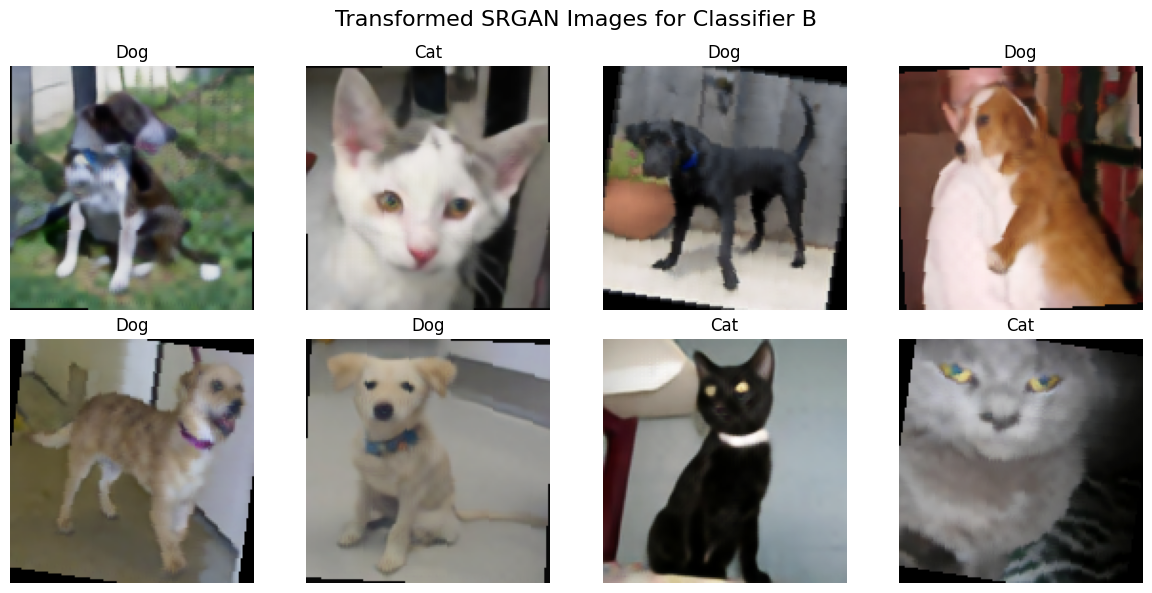

Saved: /content/drive/MyDrive/AI_Midterm/figures/classifier_B/classifier_B_transformed_samples.png


In [ ]:
import random
import matplotlib.pyplot as plt


def denormalize_image(
    image_tensor,
    mean=IMAGENET_MEAN,
    std=IMAGENET_STD,
):
    image = image_tensor.clone()

    mean_tensor = image.new_tensor(
        mean
    ).view(3, 1, 1)

    std_tensor = image.new_tensor(
        std
    ).view(3, 1, 1)

    image = (
        image * std_tensor
        + mean_tensor
    )

    return image.clamp(
        0,
        1
    )


sample_indices = random.sample(
    range(len(train_dataset)),
    8
)

transformed_samples_path = (
    CLASSIFIER_B_FIGURES_DIR
    / "classifier_B_transformed_samples.png"
)

plt.figure(
    figsize=(12, 6)
)

for plot_index, dataset_index in enumerate(
    sample_indices
):
    image_tensor, label = (
        train_dataset[dataset_index]
    )

    display_image = denormalize_image(
        image_tensor
    )

    display_image = (
        display_image
        .permute(1, 2, 0)
        .cpu()
        .numpy()
    )

    class_name = (
        "Cat"
        if label == 0
        else "Dog"
    )

    plt.subplot(
        2,
        4,
        plot_index + 1
    )

    plt.imshow(display_image)
    plt.title(class_name)
    plt.axis("off")

plt.suptitle(
    "Transformed SRGAN Images for Classifier B",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    transformed_samples_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    transformed_samples_path
)

In [ ]:
import torch

from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)

print(
    "Training batches:",
    len(train_loader)
)

print(
    "Testing batches:",
    len(test_loader)
)

images, labels = next(
    iter(train_loader)
)

print(
    "Batch image shape:",
    images.shape
)

print(
    "Batch label shape:",
    labels.shape
)

print(
    "Labels in sample batch:",
    labels[:10].tolist()
)

Training batches: 172
Testing batches: 74
Batch image shape: torch.Size([64, 3, 128, 128])
Batch label shape: torch.Size([64])
Labels in sample batch: [0, 1, 1, 0, 1, 1, 1, 1, 1, 0]


In [ ]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Device: cuda
GPU: NVIDIA A100-SXM4-80GB


In [ ]:
import torch.nn as nn

from torchvision import models
from torchvision.models import (
    MobileNet_V2_Weights,
)

weights = (
    MobileNet_V2_Weights.DEFAULT
)

classifier_b_model = (
    models.mobilenet_v2(
        weights=weights
    )
)

for parameter in (
    classifier_b_model
    .features
    .parameters()
):
    parameter.requires_grad = False

input_features = (
    classifier_b_model
    .classifier[1]
    .in_features
)

classifier_b_model.classifier[1] = (
    nn.Linear(
        input_features,
        2
    )
)

classifier_b_model = (
    classifier_b_model.to(device)
)

print(classifier_b_model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [ ]:
trainable_parameters = [
    name
    for name, parameter
    in classifier_b_model.named_parameters()
    if parameter.requires_grad
]

print("Trainable parameters:")

for name in trainable_parameters:
    print(name)

Trainable parameters:
classifier.1.weight
classifier.1.bias


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    classifier_b_model.classifier.parameters(),
    lr=1e-4,
)

NUM_EPOCHS = 10

BEST_CHECKPOINT_PATH = (
    CLASSIFIER_B_CHECKPOINT_DIR
    / "classifier_B_best.pth"
)

FINAL_CHECKPOINT_PATH = (
    CLASSIFIER_B_CHECKPOINT_DIR
    / "classifier_B_final.pth"
)

print("Epochs:", NUM_EPOCHS)
print("Learning rate:", 1e-4)
print("Best checkpoint:", BEST_CHECKPOINT_PATH)
print("Final checkpoint:", FINAL_CHECKPOINT_PATH)

Epochs: 10
Learning rate: 0.0001
Best checkpoint: /content/drive/MyDrive/AI_Midterm/checkpoints/classifier_B/classifier_B_best.pth
Final checkpoint: /content/drive/MyDrive/AI_Midterm/checkpoints/classifier_B/classifier_B_final.pth


In [ ]:
images, labels = next(
    iter(train_loader)
)

images = images.to(device)
labels = labels.to(device)

classifier_b_model.eval()

with torch.no_grad():
    outputs = classifier_b_model(images)

print("Input batch shape:", images.shape)
print("Output batch shape:", outputs.shape)
print("Label batch shape:", labels.shape)

Input batch shape: torch.Size([64, 3, 128, 128])
Output batch shape: torch.Size([64, 2])
Label batch shape: torch.Size([64])


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

Training batches: 172
Testing batches: 74


In [ ]:
import time

loader_start = time.time()

images, labels = next(iter(train_loader))

print("Batch loaded successfully.")
print("Batch shape:", images.shape)
print(
    "Loading time:",
    round(time.time() - loader_start, 2),
    "seconds"
)

Batch loaded successfully.
Batch shape: torch.Size([64, 3, 128, 128])
Loading time: 0.29 seconds


In [ ]:
import time

best_test_loss = float("inf")

classifier_b_history = {
    "train_loss": [],
    "train_accuracy": [],
    "test_loss": [],
    "test_accuracy": [],
}

training_start_time = time.time()

for epoch in range(NUM_EPOCHS):

    epoch_start_time = time.time()

    # -------------------------
    # Training phase
    # -------------------------
    classifier_b_model.train()

    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = classifier_b_model(
            images
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        running_train_loss += (
            loss.item()
            * labels.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)

    train_loss = (
        running_train_loss
        / train_total
    )

    train_accuracy = (
        train_correct
        / train_total
    )

    # -------------------------
    # Testing phase
    # -------------------------
    classifier_b_model.eval()

    running_test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = classifier_b_model(
                images
            )

            loss = criterion(
                outputs,
                labels
            )

            running_test_loss += (
                loss.item()
                * labels.size(0)
            )

            predictions = outputs.argmax(
                dim=1
            )

            test_correct += (
                predictions == labels
            ).sum().item()

            test_total += labels.size(0)

    test_loss = (
        running_test_loss
        / test_total
    )

    test_accuracy = (
        test_correct
        / test_total
    )

    classifier_b_history[
        "train_loss"
    ].append(train_loss)

    classifier_b_history[
        "train_accuracy"
    ].append(train_accuracy)

    classifier_b_history[
        "test_loss"
    ].append(test_loss)

    classifier_b_history[
        "test_accuracy"
    ].append(test_accuracy)

    epoch_time = (
        time.time()
        - epoch_start_time
    )

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_accuracy:.4f} | "
        f"Time: {epoch_time / 60:.2f} min"
    )

    # Save the best-performing model
    if test_loss < best_test_loss:

        best_test_loss = test_loss

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict":
                    classifier_b_model.state_dict(),
                "optimizer_state_dict":
                    optimizer.state_dict(),
                "test_loss": test_loss,
                "test_accuracy":
                    test_accuracy,
                "history":
                    classifier_b_history,
            },
            BEST_CHECKPOINT_PATH,
        )

        print(
            "Best checkpoint saved."
        )

total_training_time = (
    time.time()
    - training_start_time
)

print(
    "\nTraining complete."
)

print(
    "Total training time:",
    f"{total_training_time / 60:.2f} minutes"
)

Epoch 01/10 | Train Loss: 0.4718 | Train Acc: 0.8209 | Test Loss: 0.4268 | Test Acc: 0.8332 | Time: 13.02 min
Best checkpoint saved.
Epoch 02/10 | Train Loss: 0.3868 | Train Acc: 0.8499 | Test Loss: 0.3754 | Test Acc: 0.8523 | Time: 1.09 min
Best checkpoint saved.
Epoch 03/10 | Train Loss: 0.3480 | Train Acc: 0.8617 | Test Loss: 0.3447 | Test Acc: 0.8599 | Time: 1.08 min
Best checkpoint saved.
Epoch 04/10 | Train Loss: 0.3294 | Train Acc: 0.8664 | Test Loss: 0.3292 | Test Acc: 0.8676 | Time: 1.08 min
Best checkpoint saved.
Epoch 05/10 | Train Loss: 0.3157 | Train Acc: 0.8672 | Test Loss: 0.3195 | Test Acc: 0.8720 | Time: 1.08 min
Best checkpoint saved.
Epoch 06/10 | Train Loss: 0.3060 | Train Acc: 0.8705 | Test Loss: 0.3128 | Test Acc: 0.8695 | Time: 1.10 min
Best checkpoint saved.
Epoch 07/10 | Train Loss: 0.2967 | Train Acc: 0.8726 | Test Loss: 0.2983 | Test Acc: 0.8754 | Time: 1.09 min
Best checkpoint saved.
Epoch 08/10 | Train Loss: 0.2954 | Train Acc: 0.8774 | Test Loss: 0.2972 | 

In [ ]:
torch.save(
    {
        "epoch": NUM_EPOCHS,
        "model_state_dict":
            classifier_b_model.state_dict(),
        "optimizer_state_dict":
            optimizer.state_dict(),
        "history":
            classifier_b_history,
        "total_training_time_seconds":
            total_training_time,
    },
    FINAL_CHECKPOINT_PATH,
)

print(
    "Final checkpoint saved:",
    FINAL_CHECKPOINT_PATH
)

print(
    "Best checkpoint saved:",
    BEST_CHECKPOINT_PATH
)

Final checkpoint saved: /content/drive/MyDrive/AI_Midterm/checkpoints/classifier_B/classifier_B_final.pth
Best checkpoint saved: /content/drive/MyDrive/AI_Midterm/checkpoints/classifier_B/classifier_B_best.pth


In [ ]:
best_checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=device
)

classifier_b_model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

classifier_b_model.eval()

print(
    "Loaded best checkpoint from epoch:",
    best_checkpoint["epoch"]
)

print(
    "Best test loss:",
    best_checkpoint["test_loss"]
)

print(
    "Best test accuracy:",
    best_checkpoint["test_accuracy"]
)

Loaded best checkpoint from epoch: 10
Best test loss: 0.28853338086544356
Best test accuracy: 0.8803056027164686


In [ ]:
all_labels = []
all_predictions = []
all_probabilities = []

classifier_b_model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = classifier_b_model(images)

        probabilities = torch.softmax(
            outputs,
            dim=1
        )[:, 1]

        predictions = outputs.argmax(
            dim=1
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities.cpu().numpy()
        )

print("Labels:", len(all_labels))
print("Predictions:", len(all_predictions))
print("Probabilities:", len(all_probabilities))

Labels: 4712
Predictions: 4712
Probabilities: 4712


In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

classifier_b_accuracy = accuracy_score(all_labels, all_predictions)
classifier_b_precision = precision_score(all_labels, all_predictions)
classifier_b_recall = recall_score(all_labels, all_predictions)
classifier_b_f1 = f1_score(all_labels, all_predictions)
classifier_b_roc_auc = roc_auc_score(all_labels, all_probabilities)

print(f"Accuracy:  {classifier_b_accuracy:.4f}")
print(f"Precision: {classifier_b_precision:.4f}")
print(f"Recall:    {classifier_b_recall:.4f}")
print(f"F1 Score:  {classifier_b_f1:.4f}")
print(f"ROC AUC:   {classifier_b_roc_auc:.4f}")

print("\nClassification Report:\n")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["Cat", "Dog"],
        digits=4,
    )
)

Accuracy:  0.8803
Precision: 0.8816
Recall:    0.8786
F1 Score:  0.8801
ROC AUC:   0.9534

Classification Report:

              precision    recall  f1-score   support

         Cat     0.8791    0.8821    0.8806      2357
         Dog     0.8816    0.8786    0.8801      2355

    accuracy                         0.8803      4712
   macro avg     0.8803    0.8803    0.8803      4712
weighted avg     0.8803    0.8803    0.8803      4712



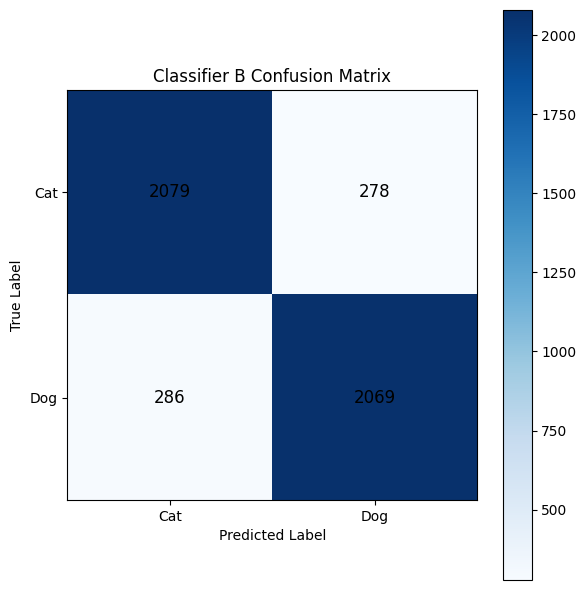

Saved: /content/drive/MyDrive/AI_Midterm/figures/classifier_B/classifier_B_confusion_matrix.png


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_predictions,
)

plt.figure(figsize=(6, 6))

plt.imshow(cm, interpolation="nearest", cmap="Blues")

plt.title("Classifier B Confusion Matrix")

plt.colorbar()

tick_marks = [0, 1]

plt.xticks(
    tick_marks,
    ["Cat", "Dog"]
)

plt.yticks(
    tick_marks,
    ["Cat", "Dog"]
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="black",
            fontsize=12,
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

confusion_matrix_path = (
    CLASSIFIER_B_FIGURES_DIR
    / "classifier_B_confusion_matrix.png"
)

plt.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    confusion_matrix_path
)

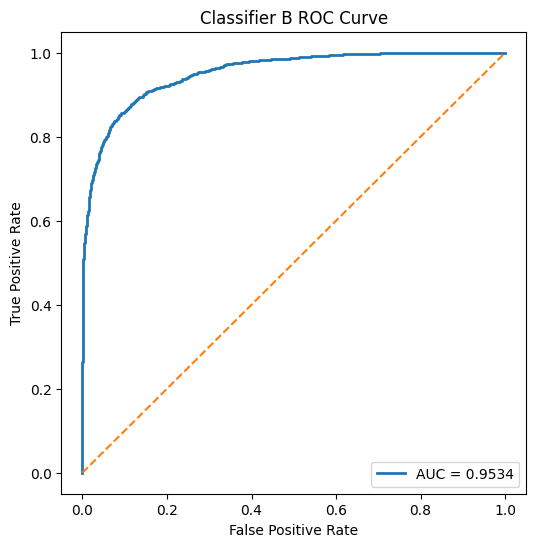

Saved: /content/drive/MyDrive/AI_Midterm/figures/classifier_B/classifier_B_ROC_curve.png


In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    all_labels,
    all_probabilities,
)

plt.figure(figsize=(6, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {classifier_b_roc_auc:.4f}",
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Classifier B ROC Curve")
plt.legend(loc="lower right")

roc_path = (
    CLASSIFIER_B_FIGURES_DIR
    / "classifier_B_ROC_curve.png"
)

plt.savefig(
    roc_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    roc_path
)

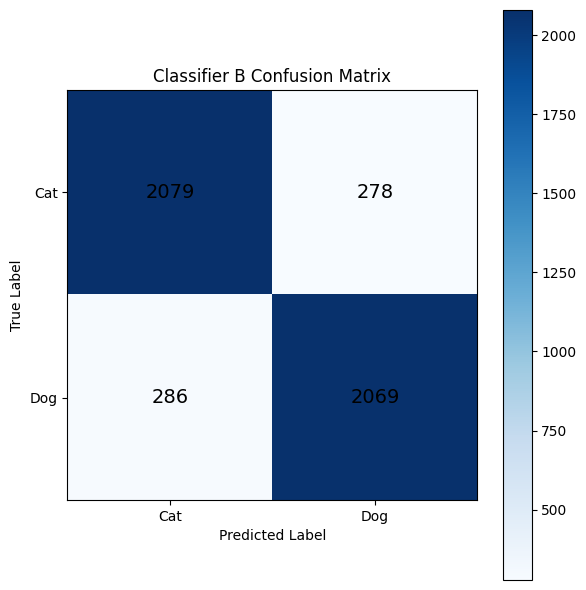

/content/drive/MyDrive/AI_Midterm/figures/classifier_B/classifier_B_confusion_matrix.png


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(6,6))
plt.imshow(cm, cmap="Blues")
plt.title("Classifier B Confusion Matrix")
plt.colorbar()

classes = ["Cat","Dog"]

plt.xticks(range(2), classes)
plt.yticks(range(2), classes)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
            fontsize=14,
            color="black"
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

confusion_matrix_path = (
    CLASSIFIER_B_FIGURES_DIR /
    "classifier_B_confusion_matrix.png"
)

plt.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(confusion_matrix_path)

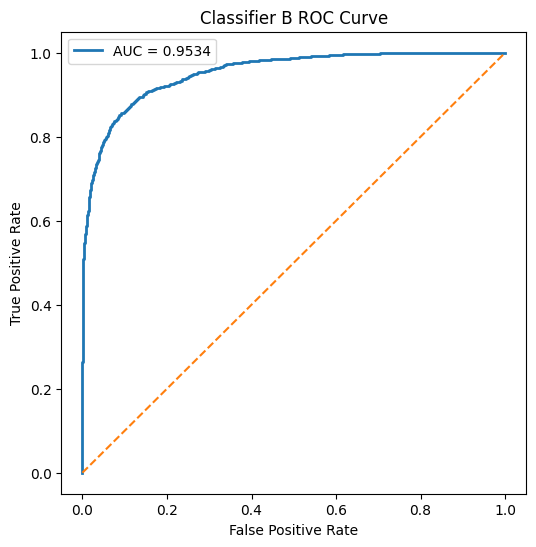

/content/drive/MyDrive/AI_Midterm/figures/classifier_B/classifier_B_ROC_curve.png


In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    all_labels,
    all_probabilities
)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {classifier_b_roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Classifier B ROC Curve")

plt.legend()

roc_curve_path = (
    CLASSIFIER_B_FIGURES_DIR /
    "classifier_B_ROC_curve.png"
)

plt.savefig(
    roc_curve_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(roc_curve_path)

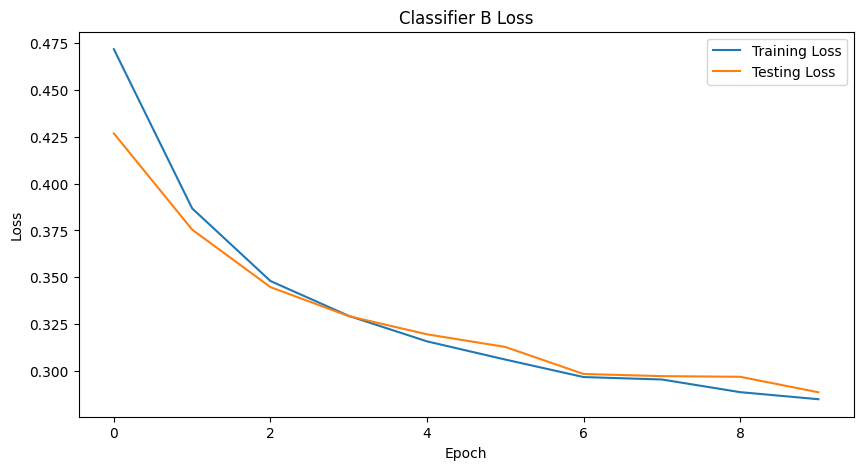

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    classifier_b_history["train_loss"],
    label="Training Loss"
)

plt.plot(
    classifier_b_history["test_loss"],
    label="Testing Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Classifier B Loss")

plt.legend()

loss_path = (
    CLASSIFIER_B_FIGURES_DIR /
    "classifier_B_loss.png"
)

plt.savefig(
    loss_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

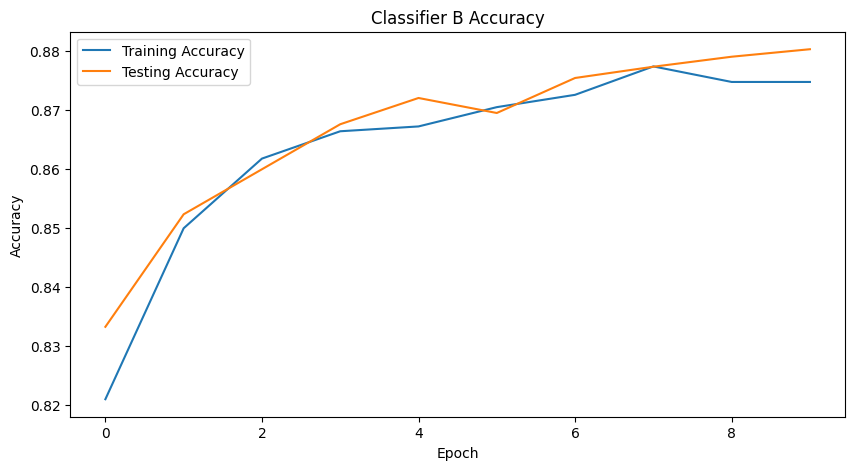

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    classifier_b_history["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    classifier_b_history["test_accuracy"],
    label="Testing Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Classifier B Accuracy")

plt.legend()

accuracy_path = (
    CLASSIFIER_B_FIGURES_DIR /
    "classifier_B_accuracy.png"
)

plt.savefig(
    accuracy_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import json

metrics = {
    "accuracy": classifier_b_accuracy,
    "precision": classifier_b_precision,
    "recall": classifier_b_recall,
    "f1_score": classifier_b_f1,
    "roc_auc": classifier_b_roc_auc,
    "best_epoch": best_checkpoint["epoch"],
    "best_test_loss": best_checkpoint["test_loss"]
}

metrics_path = (
    PROJECT_ROOT /
    "metrics" /
    "classifier_B" /
    "classifier_B_metrics.json"
)

metrics_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

with open(metrics_path,"w") as f:
    json.dump(
        metrics,
        f,
        indent=4
    )

print(metrics_path)

/content/drive/MyDrive/AI_Midterm/metrics/classifier_B/classifier_B_metrics.json


In [ ]:
print("="*60)

print("Classifier B Final Results")

print("="*60)

print(f"Accuracy : {classifier_b_accuracy:.4f}")
print(f"Precision: {classifier_b_precision:.4f}")
print(f"Recall   : {classifier_b_recall:.4f}")
print(f"F1 Score : {classifier_b_f1:.4f}")
print(f"ROC AUC  : {classifier_b_roc_auc:.4f}")

print("="*60)

print("Best Epoch:",best_checkpoint["epoch"])
print("Best Loss :",best_checkpoint["test_loss"])

print("="*60)

Classifier B Final Results
Accuracy : 0.8803
Precision: 0.8816
Recall   : 0.8786
F1 Score : 0.8801
ROC AUC  : 0.9534
Best Epoch: 10
Best Loss : 0.28853338086544356


In [ ]:
import pandas as pd

comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC AUC"
    ],

    "Classifier A":[
        # Fill these in
        None,
        None,
        None,
        None,
        None
    ],

    "Classifier B":[
        classifier_b_accuracy,
        classifier_b_precision,
        classifier_b_recall,
        classifier_b_f1,
        classifier_b_roc_auc
    ]

})

comparison

,Metric,Classifier A,Classifier B
0,Accuracy,None,0.880306
1,Precision,None,0.881551
2,Recall,None,0.878556
3,F1,None,0.880051
4,ROC AUC,None,0.953370


*Classifier B achieved 88.03% accuracy with an ROC AUC of 95.34%, demonstrating that a MobileNetV2 classifier trained on SRGAN-generated images can effectively distinguish between cats and dogs. Precision (88.16%) and recall (87.86%) were well balanced, resulting in an F1 score of 88.01%. The strong ROC AUC indicates excellent class separability. These findings suggest that super-resolution generated images can serve as a viable training dataset for downstream image classification tasks, although direct comparison with the classifier trained on original images is necessary to quantify any performance differences.*

**Discussion**

The baseline transfer-learning model (Classifier A) achieved higher performance than the classifier trained using SRGAN-generated images (Classifier B) across all evaluation metrics. While the SRGAN successfully generated realistic high-resolution images, the synthetic data did not improve binary classification performance in this experiment.

One possible explanation is that the original Dogs vs. Cats dataset already provided sufficient high-quality training examples for the baseline model. Although the SRGAN produced visually convincing images, the generated samples may not have added enough new information to improve the classifier's ability to generalize. The synthetic images may also have introduced subtle artifacts or reduced diversity that limited their benefit during training.

These findings demonstrate that the success of a generative model should not be evaluated solely by visual image quality. Instead, its impact on downstream machine learning tasks should also be assessed. In this project, the SRGAN successfully generated realistic high-resolution images, but the original transfer-learning classifier remained the better-performing model.